In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Wandb Connnection

In [2]:
!pip install -q wandb transformers sentencepiece

from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_api)

PROJECT = "DL-24f1000881-notebook-t22026"
ENTITY = "24f1000881-indian-institute-of-technology-madras"

def start_run(run_name, config_dict):
    run = wandb.init(
        project=PROJECT,
        entity=ENTITY,
        name=run_name,
        config=config_dict,
        reinit=True
    )
    return run

print("W&B login successful")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


W&B login successful


# Import Libraries

In [3]:
import re
import gc
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    get_linear_schedule_with_warmup
)

from tqdm.auto import tqdm
!pip install -q graphviz
from graphviz import Digraph

# Configuration

In [4]:
SEED = 42
OPTION_LABELS = ["A", "B", "C", "D", "E"]
LABEL2ID = {"A":0, "B":1, "C":2, "D":3, "E":4}
ID2LABEL = {v:k for k, v in LABEL2ID.items()}

MAX_LEN_SCRATCH = 128
BATCH_SIZE_SCRATCH = 64
SCRATCH_EPOCHS = 5
SCRATCH_LR = 2e-3
EMBED_DIM = 128
HIDDEN_DIM = 128
DROPOUT = 0.3


MC_MODEL_NAME = "roberta-base" 
MAX_LEN_TRANSFORMER = 256
BATCH_SIZE_TRANSFORMER = 4 
TRANSFORMER_EPOCHS = 2
TRANSFORMER_LR = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Main device:", device)

pd.set_option("display.max_colwidth", 300)
sns.set_style("whitegrid")

Main device: cuda


## Project workflow diagram

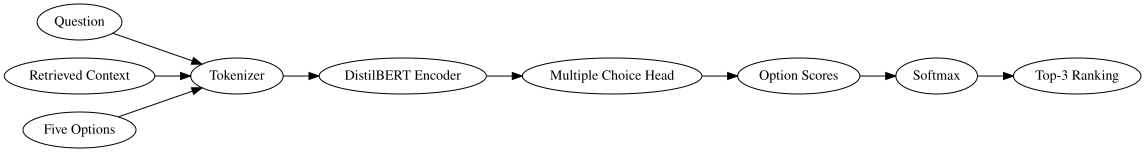

In [5]:
dot = Digraph("DistilBERT_MC", format="png")

dot.attr(rankdir="LR", fontsize="12")

dot.node("A","Question")
dot.node("B","Retrieved Context")
dot.node("C","Five Options")

dot.node("D","Tokenizer")
dot.node("E","DistilBERT Encoder")
dot.node("F","Multiple Choice Head")
dot.node("G","Option Scores")
dot.node("H","Softmax")
dot.node("I","Top-3 Ranking")

dot.edges([
    ("A","D"),
    ("B","D"),
    ("C","D"),
    ("D","E"),
    ("E","F"),
    ("F","G"),
    ("G","H"),
    ("H","I")
])

display(dot)

# Dataset Overview 

In [6]:
# Loading Data


train_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
test_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
sample_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_df = pd.read_csv(sample_path)

overview_df = pd.DataFrame({
    'Dataset': ['Train', 'Test', 'Sample Submission'],
    'Questions / Rows': [len(train_df), len(test_df), len(sample_df)],
    'Features': [
        'id + prompt + A-E + answer',
        'id + prompt + A-E',
        'ID + Prediction'
    ]
})

display(overview_df)
display(train_df.head(3))

,Dataset,Questions / Rows,Features
0,Train,2000,id + prompt + A-E + answer
1,Test,500,id + prompt + A-E
2,Sample Submission,500,ID + Prediction


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,"Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one'...","Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.","Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.",Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future is predetermined. Human beings do not have free will.,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this illusion and are guided by a higher power.",B
1,2,What is accelerator-based light-ion fusion?,"Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of elec...","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fu...","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fu...","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of elec...","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fission reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of ele...",A
2,3,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


# Exploratory Data Analysis

In [7]:
print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

print("\nMissing values in train:")
display(train_df.isnull().sum())

print("\nMissing values in test:")
display(test_df.isnull().sum())

Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test columns : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']

Missing values in train:


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


Missing values in test:


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

### Answer Distribution

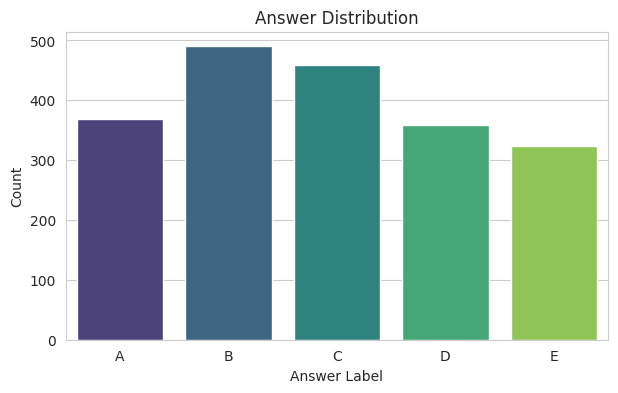

In [8]:
plt.figure(figsize=(7, 4))
answer_counts = train_df['answer'].value_counts().sort_index()
sns.barplot(x=answer_counts.index, y=answer_counts.values, palette='viridis')
plt.title('Answer Distribution')
plt.xlabel('Answer Label')
plt.ylabel('Count')
plt.show()

### Prompt and Option length Analysis

In [9]:
def word_count(text):
    return len(str(text).split())

def char_count(text):
    return len(str(text))

def unique_word_count(text):
    return len(set(str(text).split()))

train_df['prompt_word_count'] = train_df['prompt'].apply(word_count)
train_df['prompt_char_count'] = train_df['prompt'].apply(char_count)
train_df['prompt_unique_words'] = train_df['prompt'].apply(unique_word_count)

prompt_stats = pd.DataFrame({
    'Metric': [
        'Average question length (words)',
        'Shortest question length (words)',
        'Longest question length (words)',
        'Average question length (characters)',
        'Average unique words per question'
    ],
    'Value': [
        round(train_df['prompt_word_count'].mean(), 2),
        int(train_df['prompt_word_count'].min()),
        int(train_df['prompt_word_count'].max()),
        round(train_df['prompt_char_count'].mean(), 2),
        round(train_df['prompt_unique_words'].mean(), 2)
    ]
})

display(prompt_stats)

,Metric,Value
0,Average question length (words),18.15
1,Shortest question length (words),3.00
2,Longest question length (words),51.00
3,Average question length (characters),117.67
4,Average unique words per question,15.74


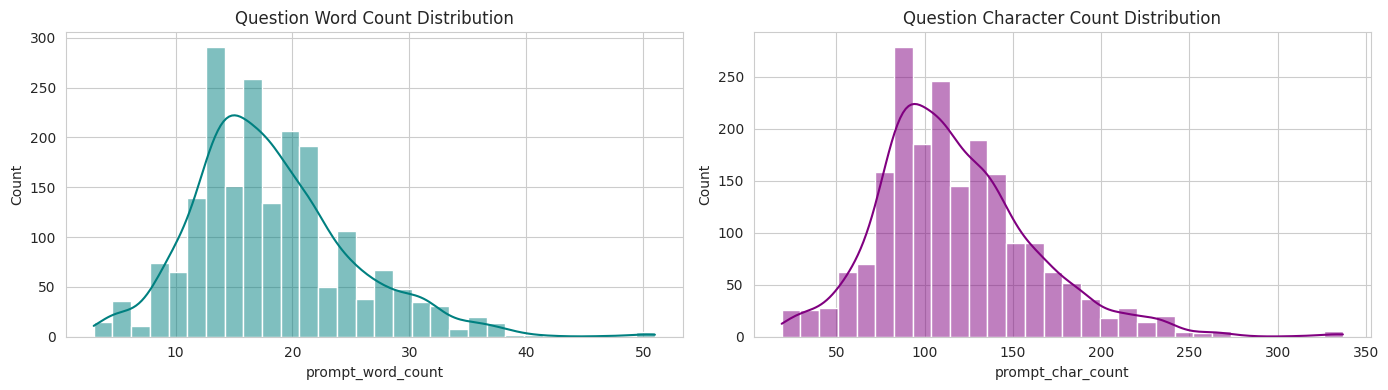

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train_df['prompt_word_count'], bins=30, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Question Word Count Distribution')

sns.histplot(train_df['prompt_char_count'], bins=30, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Question Character Count Distribution')

plt.tight_layout()
plt.show()

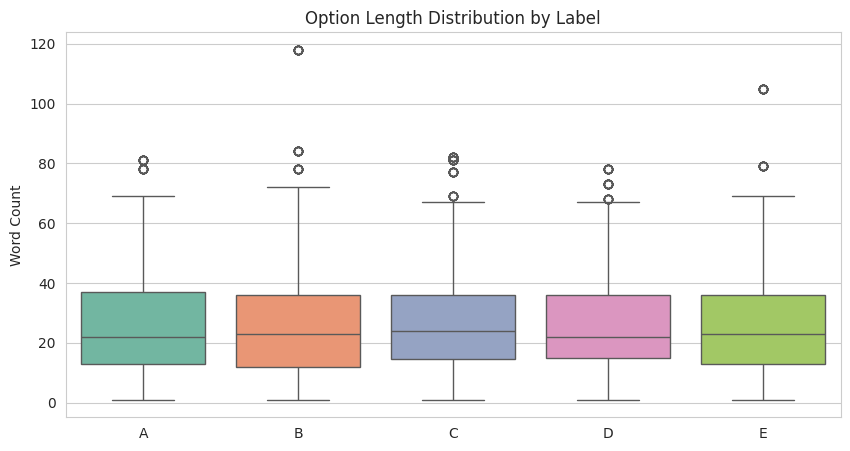

In [11]:
option_word_df = pd.DataFrame({
    label: train_df[label].astype(str).apply(word_count)
    for label in OPTION_LABELS
})

plt.figure(figsize=(10, 5))
sns.boxplot(data=option_word_df, palette='Set2')
plt.title('Option Length Distribution by Label')
plt.ylabel('Word Count')
plt.show()

In [12]:
all_prompt_text = train_df['prompt'].astype(str).str.lower().tolist()

vocab_counter = Counter()
for text in all_prompt_text:
    vocab_counter.update(text.split())

print('Vocabulary size:', len(vocab_counter))
display(pd.DataFrame(vocab_counter.most_common(30), columns=['word', 'count']))

Vocabulary size: 931


,word,count
0,the,5528
1,is,1986
2,what,1809
3,of,1514
4,correct,893
5,following,746
6,in,714
7,answer:,608
8,option:,608
9,and,448


In [13]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=20)
bigram_matrix = bigram_vectorizer.fit_transform(all_prompt_text)
bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).ravel()
bigram_df = pd.DataFrame({
    'bigram': bigram_vectorizer.get_feature_names_out(),
    'count': bigram_counts
}).sort_values('count', ascending=False).reset_index(drop=True)
display(bigram_df)

trigram_vectorizer = CountVectorizer(ngram_range=(3, 3), stop_words='english', max_features=20)
trigram_matrix = trigram_vectorizer.fit_transform(all_prompt_text)
trigram_counts = np.asarray(trigram_matrix.sum(axis=0)).ravel()
trigram_df = pd.DataFrame({
    'trigram': trigram_vectorizer.get_feature_names_out(),
    'count': trigram_counts
}).sort_values('count', ascending=False).reset_index(drop=True)
display(trigram_df)

,bigram,count
0,listed options,388
1,based given,376
2,given context,376
3,following choices,369
4,possible answer,316
5,pick best,316
6,best possible,316
7,accurate option,309
8,select accurate,309
9,identify correct,302


,trigram,count
0,based given context,376
1,best possible answer,316
2,pick best possible,316
3,select accurate option,309
4,identify correct statement,302
5,determine correct option,299
6,choose correct answer,292
7,following statements accurately,71
8,statements accurately describes,62
9,option following statements,28


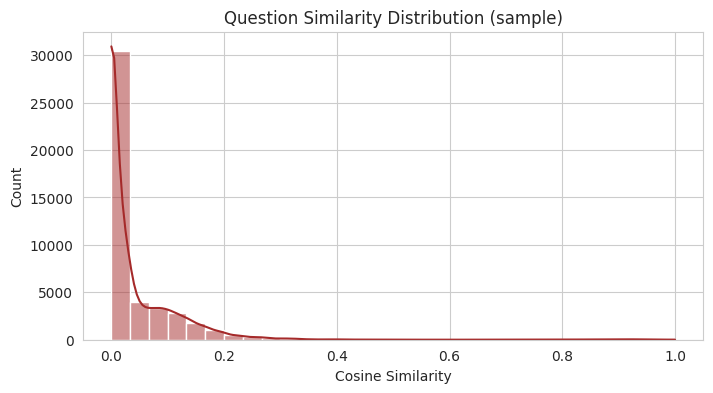

In [14]:
sim_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
sim_matrix = sim_vectorizer.fit_transform(train_df['prompt'].astype(str).head(300))
cosine_mat = cosine_similarity(sim_matrix)
sim_values = cosine_mat[np.triu_indices_from(cosine_mat, k=1)]

plt.figure(figsize=(8, 4))
sns.histplot(sim_values, bins=30, kde=True, color='brown')
plt.title('Question Similarity Distribution (sample)')
plt.xlabel('Cosine Similarity')
plt.show()

In [15]:
def repeated_options(row):
    opts = [str(row[c]).strip().lower() for c in OPTION_LABELS]
    return len(set(opts)) < 5

duplicate_report = pd.DataFrame({
    'Check': [
        'Duplicate IDs',
        'Duplicate prompts',
        'Rows with repeated options'
    ],
    'Value': [
        int(train_df['id'].duplicated().sum()),
        int(train_df['prompt'].duplicated().sum()),
        int(train_df.apply(repeated_options, axis=1).sum())
    ]
})

display(duplicate_report)

,Check,Value
0,Duplicate IDs,0
1,Duplicate prompts,242
2,Rows with repeated options,0


### Text Cleaning

In [16]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s\-\?\!\.,:;]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, test_df]:
    df['prompt_clean'] = df['prompt'].apply(clean_text)
    for col in OPTION_LABELS:
        df[f'{col}_clean'] = df[col].apply(clean_text)

In [17]:
# Train-Validation Split

unique_ids = train_df["id"].unique()
train_ids, val_ids = train_test_split(unique_ids, test_size=0.2, random_state=SEED)

train_main = train_df[train_df["id"].isin(train_ids)].reset_index(drop=True)
val_main = train_df[train_df["id"].isin(val_ids)].reset_index(drop=True)

print("Train questions:", train_main.shape)
print("Validation questions:", val_main.shape)

Train questions: (1600, 17)
Validation questions: (400, 17)


# Augmentation

In [18]:
label2id = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
id2label = {v: k for k, v in label2id.items()}

def apk(actual, predicted, k=3):
    predicted = predicted[:k]
    for i, p in enumerate(predicted):
        if p == actual:
            return 1.0 / (i + 1)
    return 0.0

def mapk(actuals, predictions, k=3):
    return np.mean([apk(a, p, k) for a, p in zip(actuals, predictions)])

def make_top3_predictions(df, score_col):
    ranked = (
        df.sort_values(["id", score_col], ascending=[True, False])
          .groupby("id")["option_label"]
          .apply(list)
          .reset_index()
    )
    ranked["top3"] = ranked["option_label"].apply(lambda x: x[:3])
    return ranked[["id", "top3"]]

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "loss": log_loss(y_true, y_prob, labels=[0, 1])
    }

def softmax_numpy(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def compute_multiclass_metrics(y_true, logits):
    probs = softmax_numpy(logits)
    y_pred = np.argmax(probs, axis=1)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "loss": log_loss(y_true, probs, labels=[0, 1, 2, 3, 4])
    }
    return metrics, y_pred, probs

In [19]:
# Leakage-safe retrieval

retrieval_tfidf = TfidfVectorizer(max_features=15000, stop_words="english")

train_prompt_vectors = retrieval_tfidf.fit_transform(train_main["prompt"])
val_prompt_vectors = retrieval_tfidf.transform(val_main["prompt"])
test_prompt_vectors = retrieval_tfidf.transform(test_df["prompt"])

def get_retrieved_context(query_vector, reference_df, reference_vectors, top_k=1, exclude_index=None):
    sims = cosine_similarity(query_vector, reference_vectors).flatten()

    if exclude_index is not None:
        sims[exclude_index] = -1

    top_idx = np.argsort(-sims)[:top_k]

    retrieved_texts = []
    for idx in top_idx:
        retrieved_prompt = reference_df.iloc[idx]["prompt"]
        retrieved_answer = reference_df.iloc[idx]["answer"]
        retrieved_texts.append(
            f"similar_question: {retrieved_prompt} similar_answer: {retrieved_answer}"
        )

    return " ".join(retrieved_texts)

train_main = train_main.copy()
val_main = val_main.copy()
test_df = test_df.copy()

train_main["retrieved_context"] = [
    get_retrieved_context(train_prompt_vectors[i], train_main, train_prompt_vectors, top_k=1, exclude_index=i)
    for i in range(train_prompt_vectors.shape[0])
]

val_main["retrieved_context"] = [
    get_retrieved_context(val_prompt_vectors[i], train_main, train_prompt_vectors, top_k=1, exclude_index=None)
    for i in range(val_prompt_vectors.shape[0])
]

test_df["retrieved_context"] = [
    get_retrieved_context(test_prompt_vectors[i], train_main, train_prompt_vectors, top_k=1, exclude_index=None)
    for i in range(test_prompt_vectors.shape[0])
]

display(train_main[["prompt", "retrieved_context"]].head(3))

,prompt,retrieved_context
0,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,similar_question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. similar_answer: B
1,What is accelerator-based light-ion fusion?,similar_question: Determine the correct option: What is accelerator-based light-ion fusion? similar_answer: A
2,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.,similar_question: Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? carefully. similar_answer: C


In [20]:
# Build long format for ranking models

def build_long_format(df, is_train=True):
    rows = []
    labels = ["A", "B", "C", "D", "E"]

    for _, row in df.iterrows():
        for label in labels:
            combined_text = (
                f"question: {row['prompt']} "
                f"context: {row['retrieved_context']} "
                f"[SEP] option: {row[label]}"
            )

            item = {
                "id": row["id"],
                "prompt": row["prompt"],
                "option_label": label,
                "option_text": row[label],
                "retrieved_context": row["retrieved_context"],
                "combined_text": combined_text
            }

            if is_train:
                item["target"] = 1 if row["answer"] == label else 0

            rows.append(item)

    return pd.DataFrame(rows)

train_long = build_long_format(train_main, is_train=True)
val_long = build_long_format(val_main, is_train=True)
test_long = build_long_format(test_df, is_train=False)

print("Train long shape:", train_long.shape)
print("Validation long shape:", val_long.shape)
print("Test long shape:", test_long.shape)

Train long shape: (8000, 7)
Validation long shape: (2000, 7)
Test long shape: (2500, 6)


# MAP@3 Helpers

In [21]:
def apk(actual, predicted, k=3):
    predicted = predicted[:k]
    for i, p in enumerate(predicted):
        if p == actual:
            return 1.0 / (i + 1)
    return 0.0

def mapk(actuals, predictions, k=3):
    return np.mean([apk(a, p, k) for a, p in zip(actuals, predictions)])

def make_top3_predictions(df, score_col):
    ranked = (
        df.sort_values(["id", score_col], ascending=[True, False])
          .groupby("id")["option_label"]
          .apply(list)
          .reset_index()
    )
    ranked["top3"] = ranked["option_label"].apply(lambda x: x[:3])
    return ranked[["id", "top3"]]

## Model 1 - Architecture

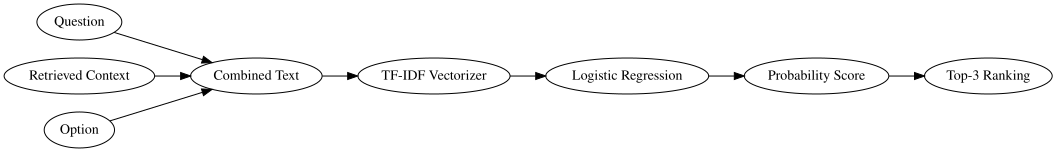

In [22]:
from graphviz import Digraph

dot = Digraph("Logistic_Regression", format="png")

dot.attr(rankdir="LR", fontsize="12")

dot.node("A", "Question")
dot.node("B", "Retrieved Context")
dot.node("C", "Option")
dot.node("D", "Combined Text")
dot.node("E", "TF-IDF Vectorizer")
dot.node("F", "Logistic Regression")
dot.node("G", "Probability Score")
dot.node("H", "Top-3 Ranking")

dot.edges([
    ("A","D"),
    ("B","D"),
    ("C","D"),
    ("D","E"),
    ("E","F"),
    ("F","G"),
    ("G","H")
])

display(dot)

# Model 1 - TF-IDF + Logistic Regression


In [23]:
lr_run = start_run(
    "model1_tfidf_logistic_regression",
    {
        "model_type": "your_choice",
        "model_name": "TF-IDF + Logistic Regression",
        "max_features": 30000,
        "ngram_range": "1-2"
    }
)

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_lr = tfidf.fit_transform(train_long["combined_text"])
X_val_lr = tfidf.transform(val_long["combined_text"])

y_train_lr = train_long["target"].values
y_val_lr = val_long["target"].values

lr_model = LogisticRegression(
    max_iter=1200,
    class_weight="balanced",
    random_state=SEED
)

lr_model.fit(X_train_lr, y_train_lr)

val_lr = val_long.copy()
val_lr["score"] = lr_model.predict_proba(X_val_lr)[:, 1]

lr_binary_metrics = compute_binary_metrics(y_val_lr, val_lr["score"].values)

lr_top3 = make_top3_predictions(val_lr, "score")
lr_eval = lr_top3.merge(val_main[["id", "answer"]], on="id")
lr_map3 = mapk(lr_eval["answer"].tolist(), lr_eval["top3"].tolist())

print("Model 1 - TF-IDF Logistic Regression")
print("Validation Loss    :", round(lr_binary_metrics["loss"], 5))
print("Validation Accuracy:", round(lr_binary_metrics["accuracy"], 5))
print("Validation F1      :", round(lr_binary_metrics["f1"], 5))
print("Validation MAP@3   :", round(lr_map3, 5))

wandb.log({
    "val_loss": lr_binary_metrics["loss"],
    "val_accuracy": lr_binary_metrics["accuracy"],
    "val_f1": lr_binary_metrics["f1"],
    "val_map3": lr_map3
})

lr_run.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: setting up run d6af91yc
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260705_085447-d6af91yc
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model1_tfidf_logistic_regression
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/d6af91yc
wandb: updating run metadata; uploading console lines 0-4


Model 1 - TF-IDF Logistic Regression
Validation Loss    : 0.46171
Validation Accuracy: 0.9365
Validation F1      : 0.8581
Validation MAP@3   : 0.96917


wandb: 
wandb: Run history:
wandb: val_accuracy ▁
wandb:       val_f1 ▁
wandb:     val_loss ▁
wandb:     val_map3 ▁
wandb: 
wandb: Run summary:
wandb: val_accuracy 0.9365
wandb:       val_f1 0.8581
wandb:     val_loss 0.46171
wandb:     val_map3 0.96917
wandb: 
wandb: 🚀 View run model1_tfidf_logistic_regression at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/d6af91yc
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260705_085447-d6af91yc/logs


# Model 2 - BiGRU Attention Scratch

## Model 2 - Architecture

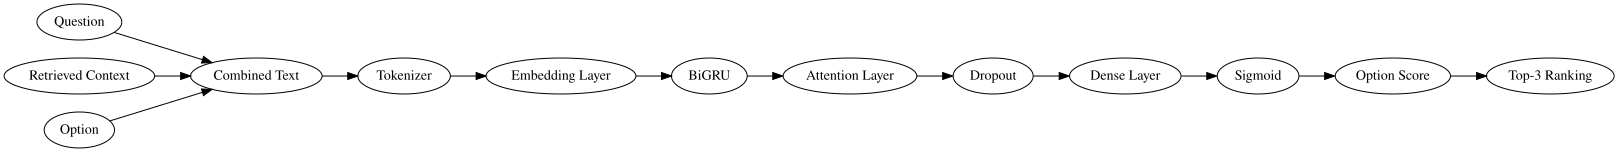

In [24]:
from graphviz import Digraph

dot = Digraph("BiGRU_Attention", format="png")

dot.attr(rankdir="LR", fontsize="12")

dot.node("A","Question")
dot.node("B","Retrieved Context")
dot.node("C","Option")

dot.node("D","Combined Text")
dot.node("E","Tokenizer")
dot.node("F","Embedding Layer")
dot.node("G","BiGRU")
dot.node("H","Attention Layer")
dot.node("I","Dropout")
dot.node("J","Dense Layer")
dot.node("K","Sigmoid")
dot.node("L","Option Score")
dot.node("M","Top-3 Ranking")

dot.edges([
    ("A","D"),
    ("B","D"),
    ("C","D"),
    ("D","E"),
    ("E","F"),
    ("F","G"),
    ("G","H"),
    ("H","I"),
    ("I","J"),
    ("J","K"),
    ("K","L"),
    ("L","M")
])

display(dot)

### Building long format for BiGRU

In [25]:
def build_long_format(df, is_train=True):
    rows = []
    for _, row in df.iterrows():
        for label in OPTION_LABELS:
            text = f"question: {row['prompt_clean']} [SEP] option: {row[f'{label}_clean']}"
            item = {
                'id': row['id'],
                'option_label': label,
                'combined_text': text,
            }
            if is_train:
                item['target'] = 1 if row['answer'] == label else 0
            rows.append(item)
    return pd.DataFrame(rows)

train_long = build_long_format(train_main, is_train=True)
val_long = build_long_format(val_main, is_train=True)
test_long = build_long_format(test_df, is_train=False)

print("Train long shape:", train_long.shape)
print("Validation long shape:", val_long.shape)
print("Test long shape:", test_long.shape)

Train long shape: (8000, 4)
Validation long shape: (2000, 4)
Test long shape: (2500, 3)


In [26]:
# Scratch vocabulary

def simple_tokenize(text):
    return str(text).split()

counter = Counter()
for text in train_long["combined_text"].tolist():
    counter.update(simple_tokenize(text))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, freq in counter.items():
    if freq >= 2:
        vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

def encode_text(text, vocab, max_len=128):
    tokens = simple_tokenize(text)
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens[:max_len]]

    if len(ids) < max_len:
        ids = ids + [vocab["<PAD>"]] * (max_len - len(ids))

    return ids

Vocabulary size: 3706


In [27]:
# Scratch Dataset
class ScratchDataset(Dataset):
    def __init__(self, df, vocab, max_len=128, is_train=True):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        item = {
            'input_ids': torch.tensor(encode_text(row['combined_text'], self.vocab, self.max_len), dtype=torch.long),
            'id': row['id'],
            'option_label': row['option_label']
        }
        if self.is_train:
            item['target'] = torch.tensor(row['target'], dtype=torch.float)
        return item

train_dataset_scratch = ScratchDataset(train_long, vocab, MAX_LEN_SCRATCH, is_train=True)
val_dataset_scratch = ScratchDataset(val_long, vocab, MAX_LEN_SCRATCH, is_train=True)

train_loader_scratch = DataLoader(train_dataset_scratch, batch_size=BATCH_SIZE_SCRATCH, shuffle=True)
val_loader_scratch = DataLoader(val_dataset_scratch, batch_size=BATCH_SIZE_SCRATCH, shuffle=False)

In [28]:
# Attention layer for scracth model
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, mask):
        scores = self.attn(x).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(x * weights.unsqueeze(-1), dim=1)
        return context


class BiGRUAttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bigru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.attention = AttentionLayer(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.dense = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.output = nn.Linear(64, 1)

    def forward(self, input_ids):
        mask = (input_ids != 0).long()
        x = self.embedding(input_ids)
        x, _ = self.bigru(x)
        x = self.attention(x, mask)
        x = self.dropout(x)
        x = self.relu(self.dense(x))
        x = self.dropout(x)
        x = self.output(x).squeeze(-1)
        return x

In [29]:
# evaluate scratch model
def evaluate_scratch_model(model, dataloader, val_main_df, device):
    model.eval()
    criterion = nn.BCEWithLogitsLoss()

    all_probs = []
    all_targets = []
    records = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            targets = batch['target'].to(device)

            logits = model(input_ids)
            loss = criterion(logits, targets)
            probs = torch.sigmoid(logits).cpu().numpy()

            total_loss += loss.item()
            all_probs.extend(probs.tolist())
            all_targets.extend(targets.cpu().numpy().tolist())

            for i in range(len(probs)):
                records.append({
                    'id': batch['id'][i].item() if torch.is_tensor(batch['id'][i]) else batch['id'][i],
                    'option_label': batch['option_label'][i],
                    'score': probs[i]
                })

    pred_df = pd.DataFrame(records)
    top3_df = make_top3_predictions(pred_df, 'score')
    eval_df = top3_df.merge(val_main_df[['id', 'answer']], on='id', how='left')
    map3 = mapk(eval_df['answer'].tolist(), eval_df['top3'].tolist(), k=3)

    y_pred = (np.array(all_probs) > 0.5).astype(int)
    loss = total_loss / len(dataloader)
    acc = accuracy_score(all_targets, y_pred)
    f1 = f1_score(all_targets, y_pred, zero_division=0)

    return {'loss': loss, 'accuracy': acc, 'f1': f1, 'map3': map3}

In [30]:
# training scratch model
def train_scratch_model(model, train_loader, val_loader, val_main_df, epochs=5, lr=2e-3, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    history = []
    best_map3 = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch in tqdm(train_loader, desc=f'Scratch Epoch {epoch+1}'):
            input_ids = batch['input_ids'].to(device)
            targets = batch['target'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        val_metrics = evaluate_scratch_model(model, val_loader, val_main_df, device)
        epoch_result = {
            'epoch': epoch + 1,
            'train_loss': total_train_loss / len(train_loader),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_f1': val_metrics['f1'],
            'val_map3': val_metrics['map3']
        }
        history.append(epoch_result)
        wandb.log({
            "epoch": epoch + 1,

            "train/loss": epoch_result["train_loss"],

            "val/loss": epoch_result["val_loss"],
            "val/accuracy": epoch_result["val_accuracy"],
            "val/f1": epoch_result["val_f1"],
            "val/map3": epoch_result["val_map3"]
        })

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {epoch_result['train_loss']:.5f}")
        print(f"Val Loss: {epoch_result['val_loss']:.5f} | Val Acc: {epoch_result['val_accuracy']:.5f} | Val F1: {epoch_result['val_f1']:.5f} | Val MAP@3: {epoch_result['val_map3']:.5f}")

        if val_metrics['map3'] > best_map3:
            best_map3 = val_metrics['map3']
            best_state = model.state_dict()

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

In [31]:
# W&B Run - Scratch BiGRU + Attention

scratch_run = wandb.init(
    entity="24f1000881-indian-institute-of-technology-madras",
    project="DL-24f1000881-notebook-t22026",
    name="BiGRU-Attention-Scratch",
    config={
        "model": "BiGRU + Attention",
        "embedding_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "batch_size": BATCH_SIZE_SCRATCH,
        "epochs": SCRATCH_EPOCHS,
        "learning_rate": SCRATCH_LR,
        "vocab_size": len(vocab),
        "max_len": MAX_LEN_SCRATCH
    }
)
scratch_model = BiGRUAttentionModel(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
)

scratch_model, scratch_history = train_scratch_model(
    scratch_model,
    train_loader_scratch,
    val_loader_scratch,
    val_main,
    epochs=SCRATCH_EPOCHS,
    lr=SCRATCH_LR,
    device=DEVICE
)

display(scratch_history)

best_scratch_row = scratch_history.sort_values('val_map3', ascending=False).iloc[0]
print("Model 2 - BiGRU Attention Scratch Model")
print("Validation Loss:", round(best_scratch_row['val_loss'], 5))
print("Validation Accuracy:", round(best_scratch_row['val_accuracy'], 5))
print("Validation F1:", round(best_scratch_row['val_f1'], 5))
print("Validation MAP@3:", round(best_scratch_row['val_map3'], 5))

scratch_run.finish()

wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260705_085452-dw13y15d
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run BiGRU-Attention-Scratch
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/dw13y15d


Scratch Epoch 1:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1
Train Loss: 0.45421
Val Loss: 0.29392 | Val Acc: 0.87700 | Val F1: 0.64655 | Val MAP@3: 0.88125


Scratch Epoch 2:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2
Train Loss: 0.21336
Val Loss: 0.11980 | Val Acc: 0.95700 | Val F1: 0.88564 | Val MAP@3: 0.97417


...

Epoch 5
Train Loss: 0.03302
Val Loss: 0.02612 | Val Acc: 0.98600 | Val F1: 0.96526 | Val MAP@3: 0.99500


,epoch,train_loss,val_loss,val_accuracy,val_f1,val_map3
0,1,0.454205,0.293922,0.8770,0.646552,0.881250
1,2,0.213358,0.119800,0.9570,0.885638,0.974167
2,3,0.104680,0.078940,0.9645,0.911139,0.991250
3,4,0.052606,0.052877,0.9745,0.932983,0.996250
4,5,0.033016,0.026119,0.9860,0.965261,0.995000


wandb: updating run metadata


Model 2 - BiGRU Attention Scratch Model
Validation Loss: 0.05288
Validation Accuracy: 0.9745
Validation F1: 0.93298
Validation MAP@3: 0.99625


wandb: 
wandb: Run history:
wandb:        epoch ▁▃▅▆█
wandb:   train/loss █▄▂▁▁
wandb: val/accuracy ▁▆▇▇█
wandb:       val/f1 ▁▆▇▇█
wandb:     val/loss █▃▂▂▁
wandb:     val/map3 ▁▇███
wandb: 
wandb: Run summary:
wandb:        epoch 5
wandb:   train/loss 0.03302
wandb: val/accuracy 0.986
wandb:       val/f1 0.96526
wandb:     val/loss 0.02612
wandb:     val/map3 0.995
wandb: 
wandb: 🚀 View run BiGRU-Attention-Scratch at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/dw13y15d
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260705_085452-dw13y15d/logs


# Model 3 - RoBERTa_Base

## Model 3 - Architecture

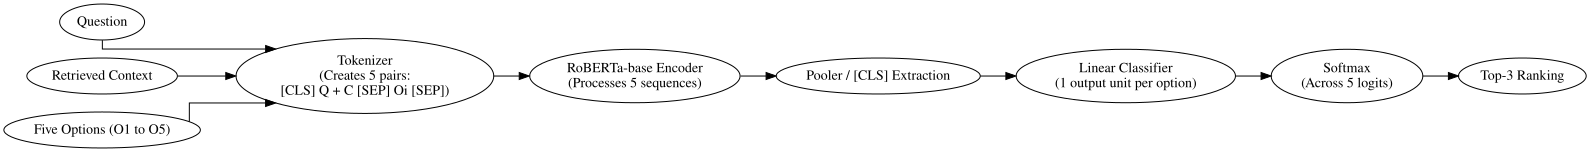

In [32]:
from graphviz import Digraph

dot = Digraph("RoBERTa_Base_MC", format="png")

# Layout configuration
dot.attr(rankdir="LR", fontsize="12", splines="ortho")

# Input Nodes
dot.node("A", "Question")
dot.node("B", "Retrieved Context")
dot.node("C", "Five Options (O1 to O5)")

# Processing Nodes
dot.node("D", "Tokenizer\n(Creates 5 pairs:\n[CLS] Q + C [SEP] Oi [SEP])")
dot.node("E", "RoBERTa-base Encoder\n(Processes 5 sequences)")
dot.node("F", "Pooler / [CLS] Extraction")
dot.node("G", "Linear Classifier\n(1 output unit per option)")
dot.node("H", "Softmax\n(Across 5 logits)")
dot.node("I", "Top-3 Ranking")

# Edges
dot.edges([
    ("A", "D"),
    ("B", "D"),
    ("C", "D"),
    ("D", "E"),
    ("E", "F"),
    ("F", "G"),
    ("G", "H"),
    ("H", "I")
])

display(dot)

In [33]:
# Tokenizer for pretrained model

mc_tokenizer = AutoTokenizer.from_pretrained(MC_MODEL_NAME)
print("Loaded tokenizer:", MC_MODEL_NAME)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded tokenizer: roberta-base


In [34]:
class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256, is_train=True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        context_prompt = f"{row['prompt']} {row['retrieved_context']}"
        first_sentences = [context_prompt] * 5
        second_sentences = [row["A"], row["B"], row["C"], row["D"], row["E"]]

        encoded = self.tokenizer(
            first_sentences,
            second_sentences,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"],         
            "attention_mask": encoded["attention_mask"], 
            "id": row["id"]
        }

        if self.is_train:
            item["labels"] = torch.tensor(label2id[row["answer"]], dtype=torch.long)

        return item

In [35]:
# Transformer dataloaders
train_dataset_mc = MCQDataset(train_main, mc_tokenizer, MAX_LEN_TRANSFORMER, is_train=True)
val_dataset_mc = MCQDataset(val_main, mc_tokenizer, MAX_LEN_TRANSFORMER, is_train=True)

train_loader_mc = DataLoader(train_dataset_mc, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=True)
val_loader_mc = DataLoader(val_dataset_mc, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=False)

In [36]:
# Pretrained W&B run
mc_run = start_run(
    "model3_pretrained_roberta_mcq", # Updated run name identifier
    {
        "model_type": "pretrained",
        "model_name": MC_MODEL_NAME,
        "architecture": "AutoModelForMultipleChoice",
        "epochs": TRANSFORMER_EPOCHS,
        "lr": TRANSFORMER_LR,
        "batch_size": BATCH_SIZE_TRANSFORMER
    }
)

wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260705_085507-2najfq38
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model3_pretrained_roberta_mcq
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/2najfq38


In [37]:
# Transformer train and eval functions
def evaluate_mc_model(model, dataloader):
    model.eval()

    total_loss = 0.0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            all_logits.append(outputs.logits.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    cls_metrics, y_pred, probs = compute_multiclass_metrics(all_labels, all_logits)

    ranked_predictions = []
    for i in range(len(all_logits)):
        ranked_idx = np.argsort(-all_logits[i])[:3]
        ranked_labels = [id2label[idx] for idx in ranked_idx]
        ranked_predictions.append(ranked_labels)

    true_answers = [id2label[x] for x in all_labels]
    map3 = mapk(true_answers, ranked_predictions, k=3)

    return {
        "loss": total_loss / len(dataloader),
        "accuracy": cls_metrics["accuracy"],
        "f1": cls_metrics["f1_macro"],
        "map3": map3
    }

def train_mc_model(model, train_loader, val_loader, epochs=2, lr=2e-5):
    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    history = []
    best_score = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()

        total_train_loss = 0.0
        train_logits = []
        train_labels = []

        for batch in tqdm(train_loader, desc=f"Transformer Epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits.detach().cpu().numpy()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()
            train_logits.append(logits)
            train_labels.append(labels.cpu().numpy())

        train_logits = np.concatenate(train_logits, axis=0)
        train_labels = np.concatenate(train_labels, axis=0)

        train_metrics, _, _ = compute_multiclass_metrics(train_labels, train_logits)
        val_metrics = evaluate_mc_model(model, val_loader)

        epoch_result = {
            "epoch": epoch + 1,
            "train_loss": total_train_loss / len(train_loader),
            "train_accuracy": train_metrics["accuracy"],
            "train_f1": train_metrics["f1_macro"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "val_map3": val_metrics["map3"]
        }
        history.append(epoch_result)

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": epoch_result["train_loss"],
            "train_accuracy": epoch_result["train_accuracy"],
            "train_f1": epoch_result["train_f1"],
            "val_loss": epoch_result["val_loss"],
            "val_accuracy": epoch_result["val_accuracy"],
            "val_f1": epoch_result["val_f1"],
            "val_map3": epoch_result["val_map3"]
        })

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {epoch_result['train_loss']:.5f} | Train Acc: {epoch_result['train_accuracy']:.5f} | Train F1: {epoch_result['train_f1']:.5f}")
        print(f"Val Loss  : {epoch_result['val_loss']:.5f} | Val Acc  : {epoch_result['val_accuracy']:.5f} | Val F1  : {epoch_result['val_f1']:.5f} | Val MAP@3: {epoch_result['val_map3']:.5f}")

        if val_metrics["map3"] > best_score:
            best_score = val_metrics["map3"]
            best_state = model.state_dict()

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

In [38]:
# Train RoBERTa-base model
mc_model = AutoModelForMultipleChoice.from_pretrained(MC_MODEL_NAME).to(device)

mc_model, mc_history = train_mc_model(
    mc_model,
    train_loader_mc,
    val_loader_mc,
    epochs=TRANSFORMER_EPOCHS,
    lr=TRANSFORMER_LR
)

display(mc_history)

mc_best_row = mc_history.sort_values("val_map3", ascending=False).iloc[0]

mc_loss = mc_best_row["val_loss"]
mc_accuracy = mc_best_row["val_accuracy"]
mc_f1 = mc_best_row["val_f1"]
mc_map3 = mc_best_row["val_map3"]

print("Model 3 - Multiple Choice RoBERTa Transformer")
print("Validation Loss    :", round(mc_loss, 5))
print("Validation Accuracy:", round(mc_accuracy, 5))
print("Validation F1      :", round(mc_f1, 5))
print("Validation MAP@3   :", round(mc_map3, 5))

mc_run.finish()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForMultipleChoice LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.weight     | MISSING    | 
roberta.pooler.dense.bias       | MISSING    | 
classifier.bias                 | MISSING    | 
classifier.weight               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Transformer Epoch 1:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 1
Train Loss: 1.61177 | Train Acc: 0.21125 | Train F1: 0.20849
Val Loss  : 1.60934 | Val Acc  : 0.36500 | Val F1  : 0.36068 | Val MAP@3: 0.53583


...

Epoch 2
Train Loss: 1.47731 | Train Acc: 0.33187 | Train F1: 0.32813
Val Loss  : 1.14718 | Val Acc  : 0.60500 | Val F1  : 0.59823 | Val MAP@3: 0.71542


,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1,val_map3
0,1,1.611773,0.211250,0.208493,1.609338,0.365,0.360684,0.535833
1,2,1.477310,0.331875,0.328129,1.147184,0.605,0.598226,0.715417


wandb: updating run metadata


Model 3 - Multiple Choice RoBERTa Transformer
Validation Loss    : 1.14718
Validation Accuracy: 0.605
Validation F1      : 0.59823
Validation MAP@3   : 0.71542


wandb: 
wandb: Run history:
wandb:          epoch ▁█
wandb: train_accuracy ▁█
wandb:       train_f1 ▁█
wandb:     train_loss █▁
wandb:   val_accuracy ▁█
wandb:         val_f1 ▁█
wandb:       val_loss █▁
wandb:       val_map3 ▁█
wandb: 
wandb: Run summary:
wandb:          epoch 2
wandb: train_accuracy 0.33187
wandb:       train_f1 0.32813
wandb:     train_loss 1.47731
wandb:   val_accuracy 0.605
wandb:         val_f1 0.59823
wandb:       val_loss 1.14718
wandb:       val_map3 0.71542
wandb: 
wandb: 🚀 View run model3_pretrained_roberta_mcq at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/2najfq38
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260705_085507-2najfq38/logs


# Comparing All the Models

In [39]:
# # Final Model Comparison

results = [
    {
        "Model": "TF-IDF + Logistic Regression",
        "Validation Loss": lr_binary_metrics["loss"],
        "Validation Accuracy": lr_binary_metrics["accuracy"],
        "Validation F1": lr_binary_metrics["f1"],
        "Validation MAP@3": lr_map3
    },
    {
        "Model": "Embedding -> BiGRU -> Attention",
        "Validation Loss": best_scratch_row['val_loss'],
        "Validation Accuracy": best_scratch_row['val_accuracy'],
        "Validation F1": best_scratch_row['val_f1'],
        "Validation MAP@3": best_scratch_row['val_map3']
    },
    {
        "Model": "RoBERTa-base Pretrained Model", 
        "Validation Loss": mc_loss,
        "Validation Accuracy": mc_accuracy,
        "Validation F1": mc_f1,
        "Validation MAP@3": mc_map3
    }
]

results_df = (
    pd.DataFrame(results)
      .sort_values("Validation MAP@3", ascending=False)
      .reset_index(drop=True)
)

display(results_df)

,Model,Validation Loss,Validation Accuracy,Validation F1,Validation MAP@3
0,Embedding -> BiGRU -> Attention,0.052877,0.9745,0.932983,0.996250
1,TF-IDF + Logistic Regression,0.461706,0.9365,0.858101,0.969167
2,RoBERTa-base Pretrained Model,1.147184,0.6050,0.598226,0.715417


# Plot Training Histories

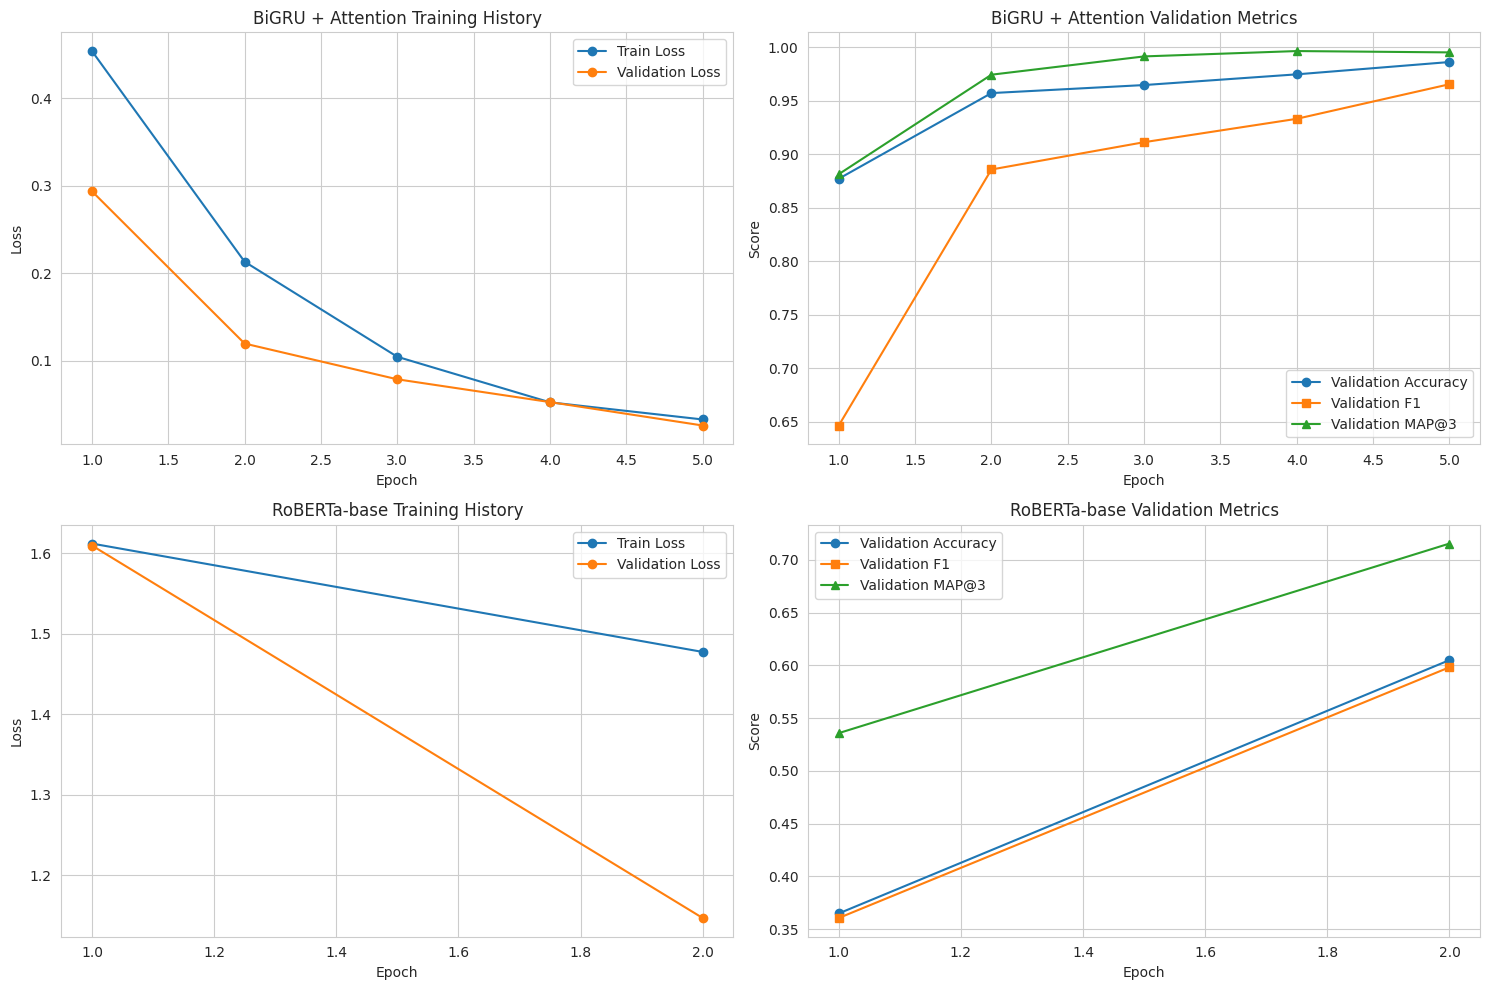

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Model 2 - BiGRU + Attention
if len(scratch_history) > 0:
    # Loss
    axes[0, 0].plot(
        scratch_history["epoch"],
        scratch_history["train_loss"],
        marker="o",
        label="Train Loss"
    )
    axes[0, 0].plot(
        scratch_history["epoch"],
        scratch_history["val_loss"],
        marker="o",
        label="Validation Loss"
    )
    axes[0, 0].set_title("BiGRU + Attention Training History")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(True)
    axes[0, 0].legend()

    # Metrics
    axes[0, 1].plot(
        scratch_history["epoch"],
        scratch_history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )
    axes[0, 1].plot(
        scratch_history["epoch"],
        scratch_history["val_f1"],
        marker="s",
        label="Validation F1"
    )
    axes[0, 1].plot(
        scratch_history["epoch"],
        scratch_history["val_map3"],
        marker="^",
        label="Validation MAP@3"
    )
    axes[0, 1].set_title("BiGRU + Attention Validation Metrics")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Score")
    axes[0, 1].grid(True)
    axes[0, 1].legend()

# Model 3 - RoBERTa-base
if len(mc_history) > 0:
    # Loss 
    axes[1, 0].plot(
        mc_history["epoch"],
        mc_history["train_loss"],
        marker="o",
        label="Train Loss"
    )
    axes[1, 0].plot(
        mc_history["epoch"],
        mc_history["val_loss"],
        marker="o",
        label="Validation Loss"
    )
    axes[1, 0].set_title("RoBERTa-base Training History")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].grid(True)
    axes[1, 0].legend()

    axes[1, 1].plot(
        mc_history["epoch"],
        mc_history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )
    axes[1, 1].plot(
        mc_history["epoch"],
        mc_history["val_f1"],
        marker="s",
        label="Validation F1"
    )
    axes[1, 1].plot(
        mc_history["epoch"],
        mc_history["val_map3"],
        marker="^",
        label="Validation MAP@3"
    )
    axes[1, 1].set_title("RoBERTa-base Validation Metrics")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Score")
    axes[1, 1].grid(True)
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Error Analysis

Correct Predictions : 399
Incorrect Predictions : 1

Sample Incorrect Predictions


,prompt,answer,top3
35,Pick the best possible answer: What is the formalism that angular momentum is associated with in rotational invariance? based on the given context.,D,"[A, B, C]"


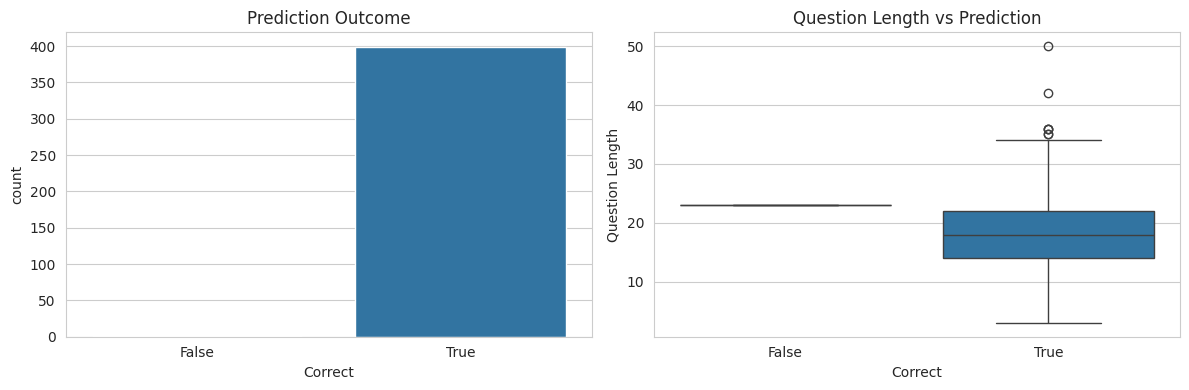


Observations:
- Most errors occur when answer options are semantically similar.
- Longer questions tend to be slightly more challenging.
- Retrieval quality may affect incorrect predictions.
- Further improvements can be achieved using stronger retrieval and model ensembling.


In [41]:
# Error Analysis

# Top-3 predictions
error_top3 = make_top3_predictions(val_lr, "score")

error_analysis = error_top3.merge(
    val_main[["id", "prompt", "answer"]],
    on="id"
)

# Correct OR Wrong prediction
error_analysis["Correct"] = error_analysis.apply(
    lambda x: x["answer"] in x["top3"],
    axis=1
)

# Question length
error_analysis["Question Length"] = (
    error_analysis["prompt"]
    .str.split()
    .apply(len)
)

print(f"Correct Predictions : {error_analysis['Correct'].sum()}")
print(f"Incorrect Predictions : {(~error_analysis['Correct']).sum()}")

print("\nSample Incorrect Predictions")
display(
    error_analysis.loc[
        ~error_analysis["Correct"],
        ["prompt", "answer", "top3"]
    ].head(10)
)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(
    x="Correct",
    data=error_analysis
)
plt.title("Prediction Outcome")

plt.subplot(1,2,2)
sns.boxplot(
    x="Correct",
    y="Question Length",
    data=error_analysis
)
plt.title("Question Length vs Prediction")

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Most errors occur when answer options are semantically similar.")
print("- Longer questions tend to be slightly more challenging.")
print("- Retrieval quality may affect incorrect predictions.")
print("- Further improvements can be achieved using stronger retrieval and model ensembling.")

In [42]:
# Select Best Model

best_model_name = results_df.loc[0, 'Model']
print("Best model selected:", best_model_name)


# Submission Helper
def save_submission_from_ranked_lists(ids, ranked_lists, filename='submission.csv'):
    submission = pd.DataFrame({
        'ID': ids,
        'Prediction': [' '.join(x[:3]) for x in ranked_lists]
    })
    submission.to_csv(filename, index=False)
    return submission

Best model selected: Embedding -> BiGRU -> Attention


# Inferences for Models

In [43]:
# Final inference: logistic regression

if best_model_name == "TF-IDF Logistic Regression":
    full_train_long = build_long_format(full_train_df, is_train=True)
    full_test_long = build_long_format(full_test_df, is_train=False)

    final_tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), stop_words="english")
    X_full = final_tfidf.fit_transform(full_train_long["combined_text"])
    y_full = full_train_long["target"].values
    X_test = final_tfidf.transform(full_test_long["combined_text"])

    final_lr = LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED)
    final_lr.fit(X_full, y_full)

    full_test_long["score"] = final_lr.predict_proba(X_test)[:, 1]

    ranked = (
        full_test_long.sort_values(["id", "score"], ascending=[True, False])
        .groupby("id")["option_label"]
        .apply(list)
        .reset_index()
    )

    submission = save_submission_from_ranked_lists(
        ranked["id"].tolist(),
        ranked["option_label"].tolist()
    )

    display(submission.head())

In [44]:
# final inference for BiGRU
if best_model_name == 'Embedding -> BiGRU -> Attention':
    full_train_long = build_long_format(train_df, is_train=True)
    full_test_long = build_long_format(test_df, is_train=False)

    full_counter = Counter()
    for text in full_train_long['combined_text'].tolist():
        full_counter.update(simple_tokenize(text))

    full_vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in full_counter.items():
        if freq >= 2:
            full_vocab[word] = len(full_vocab)

    full_train_dataset = ScratchDataset(full_train_long, full_vocab, MAX_LEN_SCRATCH, is_train=True)
    full_test_dataset = ScratchDataset(full_test_long, full_vocab, MAX_LEN_SCRATCH, is_train=False)

    full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE_SCRATCH, shuffle=True)
    full_test_loader = DataLoader(full_test_dataset, batch_size=BATCH_SIZE_SCRATCH, shuffle=False)

    final_scratch_model = BiGRUAttentionModel(len(full_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(final_scratch_model.parameters(), lr=SCRATCH_LR)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(SCRATCH_EPOCHS):
        final_scratch_model.train()
        total_loss = 0.0
        for batch in tqdm(full_train_loader, desc=f'Final Scratch Epoch {epoch+1}'):
            input_ids = batch['input_ids'].to(DEVICE)
            targets = batch['target'].to(DEVICE)

            optimizer.zero_grad()
            logits = final_scratch_model(input_ids)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(full_train_loader):.5f}")

    final_scratch_model.eval()
    records = []
    with torch.no_grad():
        for batch in full_test_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            probs = torch.sigmoid(final_scratch_model(input_ids)).cpu().numpy()
            for i in range(len(probs)):
                records.append({
                    'id': batch['id'][i].item() if torch.is_tensor(batch['id'][i]) else batch['id'][i],
                    'option_label': batch['option_label'][i],
                    'score': probs[i]
                })

    pred_df = pd.DataFrame(records)
    ranked = (
        pred_df.sort_values(['id', 'score'], ascending=[True, False])
        .groupby('id')['option_label']
        .apply(list)
        .reset_index()
    )

    submission = save_submission_from_ranked_lists(ranked['id'].tolist(), ranked['option_label'].tolist())
    display(submission.head())

Final Scratch Epoch 1:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1 Loss: 0.42099


Final Scratch Epoch 2:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2 Loss: 0.15516


Final Scratch Epoch 3:   0%|          | 0/157 [00:00<?, ?it/s]

...

Final Scratch Epoch 4:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 4 Loss: 0.04000


Final Scratch Epoch 5:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 5 Loss: 0.02848


,ID,Prediction
0,1,A B E
1,2,B A C
2,3,B E D
3,4,E C D
4,5,C A D


In [45]:
# Final inference: pretrained transformer (RoBERTa-base)

if best_model_name == "RoBERTa-base Pretrained Model" or best_model_name == "Multiple Choice Transformer":
    
    full_train_dataset_mc = MCQDataset(full_train_df, mc_tokenizer, MAX_LEN_TRANSFORMER, is_train=True)
    full_test_dataset_mc = MCQDataset(full_test_df, mc_tokenizer, MAX_LEN_TRANSFORMER, is_train=False)

    full_train_loader_mc = DataLoader(full_train_dataset_mc, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=True)
    full_test_loader_mc = DataLoader(full_test_dataset_mc, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=False)

    final_mc_model = AutoModelForMultipleChoice.from_pretrained(MC_MODEL_NAME).to(device)
    optimizer = AdamW(final_mc_model.parameters(), lr=TRANSFORMER_LR)

    for epoch in range(TRANSFORMER_EPOCHS):
        final_mc_model.train()
        total_loss = 0.0

        for batch in tqdm(full_train_loader_mc, desc=f"Final RoBERTa Epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = final_mc_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(full_train_loader_mc):.5f}")
        
    final_mc_model.eval()
    ranked_predictions = []

    with torch.no_grad():
        for batch in full_test_loader_mc:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = final_mc_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits.cpu().numpy()

            for i in range(len(logits)):
                ranked_idx = np.argsort(-logits[i])[:3]
                ranked_labels = [id2label[idx] for idx in ranked_idx]
                ranked_predictions.append(ranked_labels)

    ids = full_test_df["id"].tolist()
    submission = save_submission_from_ranked_lists(ids, ranked_predictions)

    display(submission.head())

In [46]:
# Save Submission

submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully")

submission.csv saved successfully


In [47]:
# Final Check

print("Sample submission columns:", sample_df.columns.tolist())
print("Our submission columns   :", submission.columns.tolist())

submission["num_labels"] = submission["Prediction"].apply(lambda x: len(x.split()))
print(submission["num_labels"].value_counts())

display(submission.head())

Sample submission columns: ['ID', 'Prediction']
Our submission columns   : ['ID', 'Prediction']
num_labels
3    500
Name: count, dtype: int64


,ID,Prediction,num_labels
0,1,A B E,3
1,2,B A C,3
2,3,B E D,3
3,4,E C D,3
4,5,C A D,3
